# Notebook #5 — Końcowa ocena predykcyjna augmentacji danych w estymacji temperatury magnesów trwałych `pm`

**Praca magisterska:** *Augmentacja numerycznych zbiorów uczących z wykorzystaniem metod uczenia nienadzorowanego.*
**Studium przypadku:** estymacja temperatury magnesów trwałych `pm` w silniku PMSM.

## 0. Cel notatnika i pytania badawcze

Notatnik stanowi końcowy etap potoku eksperymentalnego
(EDA → odkrywanie reżimów → segmentacja → klasteryzacja → augmentacja cluster-aware → **końcowa ocena predykcyjna**)
i dostarcza empirycznej odpowiedzi na pytanie, czy augmentacja danych — w szczególności augmentacja uwzględniająca
reżimy pracy odkryte metodami uczenia nienadzorowanego — poprawia jakość estymacji `pm` względem uczenia wyłącznie
na danych rzeczywistych. Notatnik **nie powtarza** wcześniejszych etapów (EDA, segmentacji, klasteryzacji,
generacji danych syntetycznych); wykorzystuje wyłącznie zapisane artefakty NB#2–NB#4.

**Pytania badawcze:**
- **RQ1** — Czy augmentacja poprawia predykcję `pm` względem danych wyłącznie rzeczywistych?
- **RQ2** — Czy augmentacja cluster-aware przewyższa równoważną augmentację bez informacji o reżimach (globalną)?
- **RQ3** — Czy augmentacja GAN dostarcza użytecznej informacji predykcyjnej ponad augmentację klasyczną?
- **RQ4** — Czy efekty augmentacji są spójne pomiędzy reżimami pracy (klastrami)?
- **RQ5** — Czy augmentacja poprawia wyniki dla różnych rodzin modeli, czy tylko dla wybranego estymatora?
- **RQ6** — Czy zwiększanie ilości danych syntetycznych prowadzi do monotonicznej poprawy jakości predykcji?
- **RQ7** — Czy augmentacja poprawia trudne / niedoreprezentowane reżimy kosztem pozostałych?

**Hipoteza główna (weryfikowana empirycznie, bez założenia odpowiedzi):**
*Wykorzystanie danych syntetycznych wygenerowanych na podstawie reżimów pracy zidentyfikowanych metodami uczenia
nienadzorowanego poprawia zdolność generalizacji modeli estymujących `pm` względem modeli uczonych wyłącznie na
danych rzeczywistych, a augmentacja cluster-aware zapewnia przewagę nad równoważną augmentacją globalną.*

**Zasada kontrolowanego eksperymentu:** różne zbiory TRAIN → ten sam model i te same cechy → **identyczny, niezmieniony
rzeczywisty zbiór TEST**. Jedyną zamierzoną różnicą pomiędzy eksperymentami jest skład zbioru uczącego.

## 1. Importy i konfiguracja

Pojedyncza sekcja konfiguracyjna zapewnia powtarzalność. Reprezentacja segmentów, kanały, cel, definicja cech i
konfiguracja modelu downstream są zgodne z NB#4 w celu zachowania porównywalności z wcześniejszymi wynikami pracy.

In [1]:
import gc, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore", category=UserWarning)

# --- powtarzalność ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RNG = np.random.default_rng(RANDOM_STATE)

# --- ścieżki ---
NB2_DIR = Path("regime_discovery_outputs")
NB3_DIR = Path("clustering_outputs")
NB4_DIR = Path("augmentation_outputs")
EDA_DIR = Path("eda_outputs")
RESULTS_PATH = Path("final_evaluation_outputs"); RESULTS_PATH.mkdir(exist_ok=True)
FIGURES_PATH = RESULTS_PATH / "figures"; FIGURES_PATH.mkdir(exist_ok=True)

# --- reprezentacja i cel (zgodne z NB#4) ---
SAMPLING_FREQUENCY = 2.0
FIXED_SEQUENCE_LENGTH = 128
TARGET = "pm"
CHANNELS = ["u_d", "u_q", "i_d", "i_q", "motor_speed", "torque",
            "coolant", "ambient", "pm", "stator_yoke", "stator_tooth", "stator_winding"]
CH_IX = {c: i for i, c in enumerate(CHANNELS)}
SELECTED_FEATURES = ["u_d", "u_q", "i_d", "i_q", "motor_speed", "torque", "coolant", "ambient"]
EWMA_SPANS = (8, 32)
SELECTED_CLUSTERING_METHOD = "kmeans"

# --- konfiguracja modelu boosting (identyczna z NB#4) ---
HGB_PARAMS = dict(max_iter=250, learning_rate=0.08, max_leaf_nodes=31,
                  min_samples_leaf=40, l2_regularization=1.0,
                  early_stopping=False, random_state=RANDOM_STATE)

# --- warianty udziału danych syntetycznych (eksperyment wolumenowy) ---
SYNTHETIC_RATIOS = (0.25, 0.5, 1.0)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 320, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.titlesize": 10,
                     "legend.fontsize": 7, "figure.autolayout": False})
print("Konfiguracja załadowana | TARGET =", TARGET, "| L =", FIXED_SEQUENCE_LENGTH,
      "| kanały =", len(CHANNELS))

Konfiguracja załadowana | TARGET = pm | L = 128 | kanały = 12


## 2. Wczytanie danych z poprzednich etapów

Wczytano wyłącznie zapisane artefakty NB#2 (segmentacja), NB#3 (klasteryzacja) oraz NB#4 (augmentacja).
Rzeczywista reprezentacja segmentów (`segments_all_channels.npy`, kształt *(n_segmentów, 128, 12)*) jest
zgodna z podziałem train/val/test ustalonym w NB#1. Referencyjne segmenty syntetyczne (udział = 1.0)
oraz metadane augmentacji pochodzą bezpośrednio z NB#4 — dane syntetyczne **nie są generowane ponownie**.

In [2]:
# --- metadane segmentów: indeks (NB#2) + etykiety klastrów (NB#3) ---
idx = pd.read_csv(NB2_DIR / "segments_series_index.csv")
labels = pd.read_csv(NB3_DIR / "cluster_labels.csv")
cfg4 = json.load(open(NB4_DIR / "augmentation_config.json"))
LABEL_COL = f"label_{SELECTED_CLUSTERING_METHOD}"
assert (labels["segment_id"].values == idx["segment_id"].values).all(), "Niezgodność segmentów NB#2/NB#3"

meta = idx.merge(labels[["segment_id", LABEL_COL]], on="segment_id").rename(columns={LABEL_COL: "cluster_id"})
meta["duration_s"] = (meta["end_sample"] - meta["start_sample"]) / SAMPLING_FREQUENCY

TRAIN_ROWS = np.flatnonzero((meta["split"] == "train").values)
VAL_ROWS = np.flatnonzero((meta["split"] == "val").values)
TEST_ROWS = np.flatnonzero((meta["split"] == "test").values)
CLUSTERS = np.sort(meta.loc[TRAIN_ROWS, "cluster_id"].unique())
N_CLUSTERS = len(CLUSTERS)

# --- rzeczywista reprezentacja segmentów (wszystkie kanały) ---
X_REAL = np.load(NB4_DIR / "segments_all_channels.npy")
assert X_REAL.shape == (len(meta), FIXED_SEQUENCE_LENGTH, len(CHANNELS)), "Nieoczekiwany kształt X_REAL"

# --- kontrola tożsamości zbioru TEST z NB#4 (hash SHA1) ---
TEST_HASH = hashlib.sha1(X_REAL[TEST_ROWS].tobytes()).hexdigest()
TEST_HASH_OK = (TEST_HASH == cfg4.get("test_hash"))

# --- referencyjne segmenty syntetyczne (udział = 1.0) + metadane ---
syn_ref = np.load(NB4_DIR / "synthetic_segments_reference.npz")
syn_meta = pd.read_csv(NB4_DIR / "synthetic_metadata.csv")
AVAILABLE_VARIANTS = [v for v in syn_ref.files]

VARIANT_SEGMENTS = {}   # wariant -> (segmenty (n,128,12), duration_s (n,))
for v in AVAILABLE_VARIANTS:
    seg = syn_ref[v].astype(np.float32)
    dur = syn_meta[(syn_meta.variant == v) & (syn_meta.augmentation_ratio == 1.0)]["duration_s"].to_numpy(np.float32)
    assert len(dur) == len(seg), f"Niezgodność liczby segmentów i metadanych dla {v}"
    VARIANT_SEGMENTS[v] = (seg, dur)

print(f"Segmenty rzeczywiste: {X_REAL.shape} | train={len(TRAIN_ROWS)} val={len(VAL_ROWS)} test={len(TEST_ROWS)}")
print(f"Klastry (TRAIN): {list(CLUSTERS)} | metoda: {SELECTED_CLUSTERING_METHOD}")
print(f"Dostępne warianty augmentacji (NB#4): {AVAILABLE_VARIANTS}")
print(f"Zgodność hash zbioru TEST z NB#4: {TEST_HASH_OK}")

Segmenty rzeczywiste: (1118, 128, 12) | train=734 val=190 test=194
Klastry (TRAIN): [np.int64(0), np.int64(1)] | metoda: kmeans
Dostępne warianty augmentacji (NB#4): ['CLUSTER_AWARE_CLASSICAL', 'CLUSTER_AWARE_GAN', 'GLOBAL_AUG', 'GLOBAL_GAN', 'HYBRID_AUG']
Zgodność hash zbioru TEST z NB#4: True


## 3. Kontrola spójności wariantów danych

W celu zachowania porównywalności eksperymentów zweryfikowano zgodność wymiarów, liczby kanałów oraz kompletność
metadanych każdego wariantu augmentacji. Zestawiono liczebność danych rzeczywistych i syntetycznych oraz udział
danych syntetycznych względem rzeczywistego zbioru uczącego (na poziomie segmentów).

In [3]:
N_TRAIN_SEG = len(TRAIN_ROWS)
variant_rows = []
for v, (seg, dur) in VARIANT_SEGMENTS.items():
    assert seg.shape[1:] == (FIXED_SEQUENCE_LENGTH, len(CHANNELS)), f"Zły kształt segmentów: {v}"
    assert np.isfinite(seg).all(), f"Wartości niefinite w {v}"
    variant_rows.append(dict(wariant=v, n_real_seg=N_TRAIN_SEG, n_syn_seg=len(seg),
                             udzial_syntetycznych=round(len(seg) / N_TRAIN_SEG, 3)))
VARIANT_TABLE = pd.DataFrame(variant_rows).sort_values("wariant").reset_index(drop=True)
print(VARIANT_TABLE.to_string(index=False))

# Grupowanie wariantów na potrzeby analiz porównawczych (ablacji).
GLOBAL_VARIANTS = [v for v in AVAILABLE_VARIANTS if v.startswith("GLOBAL")]
CLUSTER_VARIANTS = [v for v in AVAILABLE_VARIANTS if v.startswith("CLUSTER")]
GAN_VARIANTS = [v for v in AVAILABLE_VARIANTS if v.endswith("GAN")]
print("\nGlobalne:", GLOBAL_VARIANTS, "| Cluster-aware:", CLUSTER_VARIANTS, "| GAN:", GAN_VARIANTS)

                wariant  n_real_seg  n_syn_seg  udzial_syntetycznych
CLUSTER_AWARE_CLASSICAL         734        734                   1.0
      CLUSTER_AWARE_GAN         734        734                   1.0
             GLOBAL_AUG         734        734                   1.0
             GLOBAL_GAN         734        734                   1.0
             HYBRID_AUG         734        734                   1.0

Globalne: ['GLOBAL_AUG', 'GLOBAL_GAN'] | Cluster-aware: ['CLUSTER_AWARE_CLASSICAL', 'CLUSTER_AWARE_GAN'] | GAN: ['CLUSTER_AWARE_GAN', 'GLOBAL_GAN']


## 4. Leakage Audit — kontrola przed eksperymentem

Sekcja weryfikuje brak przecieku informacji przed rozpoczęciem eksperymentu. Kontrole obejmują rozłączność
profili train/val/test, obecność danych syntetycznych wyłącznie w zbiorze TRAIN, pochodzenie źródeł augmentacji
wyłącznie ze zbioru TRAIN oraz niezmienność rzeczywistego zbioru TEST (zgodność hash z NB#4). Nieudane kontrole
nie są ukrywane.

In [4]:
PROF = {s: set(meta.loc[meta.split == s, "profile_id"]) for s in ("train", "val", "test")}
AUDIT_PRE = {}
AUDIT_PRE["profile_train_val_test_rozlaczne"] = not (PROF["train"] & PROF["test"]) \
    and not (PROF["train"] & PROF["val"]) and not (PROF["val"] & PROF["test"])
AUDIT_PRE["podzial_zgodny_z_konfiguracja_NB4"] = (set(syn_meta.source_profile_id[syn_meta.source_profile_id >= 0])
                                                  <= PROF["train"])
AUDIT_PRE["dane_syntetyczne_tylko_TRAIN"] = bool((syn_meta["split"] == "train").all())
AUDIT_PRE["zrodla_augmentacji_tylko_TRAIN"] = bool(
    set(syn_meta.source_segment_id.dropna()) <= set(meta.loc[TRAIN_ROWS, "segment_id"]))
AUDIT_PRE["TEST_niezmieniony_zgodny_z_NB4"] = bool(TEST_HASH_OK)
AUDIT_PRE["klastry_pochodza_z_NB3"] = LABEL_COL in labels.columns

AUDIT_PRE_DF = pd.DataFrame([dict(Kontrola=k, Wynik="PASS" if v else "FAIL", Wartosc=bool(v))
                             for k, v in AUDIT_PRE.items()])
print(AUDIT_PRE_DF.to_string(index=False))
assert AUDIT_PRE_DF.Wartosc.all(), "Wykryto przeciek danych przed eksperymentem — przerwano."

                         Kontrola Wynik  Wartosc
 profile_train_val_test_rozlaczne  PASS     True
podzial_zgodny_z_konfiguracja_NB4  PASS     True
     dane_syntetyczne_tylko_TRAIN  PASS     True
   zrodla_augmentacji_tylko_TRAIN  PASS     True
   TEST_niezmieniony_zgodny_z_NB4  PASS     True
           klastry_pochodza_z_NB3  PASS     True


## 5. Przygotowanie cech i zbioru testowego

Zbiór predyktorów jest **identyczny** z NB#4: kanały elektryczne i mechaniczne, zmienne pochodne będące
tożsamościami fizycznymi (`u_s`, `i_s`, `omega`, moc pozorna `s_app`), krok czasowy `dt_s` oraz cechy wygładzone
wykładniczo (EWMA) w obrębie segmentu. Temperatury stojana celowo pominięto (są nieobserwowanymi stanami
termicznymi). Zmienna objaśniana `pm` **nie** występuje wśród predyktorów. Cechy budowane są identyczną funkcją
dla wszystkich wariantów, co eliminuje wpływ definicji cech na porównanie augmentacji.

In [5]:
def derived(X):
    """Zmienne pochodne (tożsamości matematyczne) dla tensora segmentów."""
    g = lambda c: X[:, :, CH_IX[c]]
    return dict(u_s=np.hypot(g("u_d"), g("u_q")), i_s=np.hypot(g("i_d"), g("i_q")),
                omega=g("motor_speed") * 2 * np.pi / 60)

def ewma(a, alpha):
    """Wykładnicza średnia krocząca wzdłuż osi czasu w obrębie segmentu."""
    out = np.empty_like(a)
    out[:, 0] = a[:, 0]
    for t in range(1, a.shape[1]):
        out[:, t] = alpha * a[:, t] + (1 - alpha) * out[:, t - 1]
    return out

def build_matrix(X, duration_s):
    """Buduje macierz cech na poziomie próbek oraz wektor zmiennej objaśnianej `pm` (schemat zgodny z NB#4)."""
    g = lambda c: X[:, :, CH_IX[c]]
    d = derived(X)
    dt = np.repeat((np.asarray(duration_s, np.float32) / FIXED_SEQUENCE_LENGTH)[:, None],
                   FIXED_SEQUENCE_LENGTH, axis=1)
    feats = [g(c) for c in SELECTED_FEATURES] + [d["u_s"], d["i_s"], d["omega"], d["u_s"] * d["i_s"], dt]
    names = list(SELECTED_FEATURES) + ["u_s", "i_s", "omega", "s_app", "dt_s"]
    for span in EWMA_SPANS:
        alpha = 2.0 / (span + 1)
        for nm, arr in [("i_s", d["i_s"]), ("u_s", d["u_s"]), ("coolant", g("coolant")),
                        ("motor_speed", g("motor_speed"))]:
            feats.append(ewma(arr, alpha)); names.append(f"{nm}_ewm{span}")
    F = np.stack(feats, -1).reshape(-1, len(names)).astype(np.float32)
    return F, g(TARGET).reshape(-1).astype(np.float32), names

def calculate_regression_metrics(y_true, y_pred):
    """Oblicza podstawowe metryki jakości modelu regresyjnego: RMSE, MAE, R2, nRMSE."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    rng = float(np.ptp(y_true)) if np.ptp(y_true) > 0 else 1.0
    return dict(RMSE=rmse, MAE=float(mean_absolute_error(y_true, y_pred)),
                R2=float(r2_score(y_true, y_pred)), nRMSE=rmse / rng)

# --- rzeczywisty zbiór uczący (bazowy) ---
dur_train = meta.loc[TRAIN_ROWS, "duration_s"].to_numpy(np.float32)
F_REAL, Y_REAL, FEATURE_NAMES = build_matrix(X_REAL[TRAIN_ROWS], dur_train)

# --- niezmienny, wyłącznie rzeczywisty zbiór TEST (identyczny dla każdego eksperymentu) ---
F_TEST, Y_TEST, _ = build_matrix(X_REAL[TEST_ROWS], meta.loc[TEST_ROWS, "duration_s"].to_numpy(np.float32))
TEST_CLUSTER = np.repeat(meta.loc[TEST_ROWS, "cluster_id"].to_numpy(), FIXED_SEQUENCE_LENGTH)
TEST_PROFILE = np.repeat(meta.loc[TEST_ROWS, "profile_id"].to_numpy(), FIXED_SEQUENCE_LENGTH)
# oś czasu rzeczywistego [min] zrekonstruowana z indeksów próbek segmentów
TEST_TIME_MIN = np.concatenate([
    np.linspace(r.start_sample, r.end_sample, FIXED_SEQUENCE_LENGTH) / SAMPLING_FREQUENCY / 60.0
    for r in meta.loc[TEST_ROWS].itertuples()]).astype(np.float32)

assert TARGET not in FEATURE_NAMES, "Zmienna objaśniana pm nie może występować wśród predyktorów"
assert len(Y_TEST) == len(TEST_ROWS) * FIXED_SEQUENCE_LENGTH
print(f"Cechy ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
print(f"Wiersze: TRAIN(real)={len(Y_REAL)}  TEST={len(Y_TEST)}  |  zakres pm TEST: "
      f"{Y_TEST.min():.1f}–{Y_TEST.max():.1f} K")

Cechy (21): ['u_d', 'u_q', 'i_d', 'i_q', 'motor_speed', 'torque', 'coolant', 'ambient', 'u_s', 'i_s', 'omega', 's_app', 'dt_s', 'i_s_ewm8', 'u_s_ewm8', 'coolant_ewm8', 'motor_speed_ewm8', 'i_s_ewm32', 'u_s_ewm32', 'coolant_ewm32', 'motor_speed_ewm32']
Wiersze: TRAIN(real)=93952  TEST=24832  |  zakres pm TEST: 23.0–105.9 K


## 6. Konfiguracja modeli predykcyjnych

Zastosowano cztery komplementarne rodziny modeli, aby wnioski nie zależały od pojedynczego algorytmu:
model referencyjny **Ridge** (regularyzacja wobec współliniowości cech), **Random Forest**, **KNN** oraz silny
model nieliniowy **HistGradientBoosting** (biblioteki XGBoost/LightGBM niedostępne w środowisku; HGB wykorzystuje
konfigurację NB#4). Zgodnie z zasadą kontrolowanego eksperymentu **jedna** konfiguracja modelu jest stosowana dla
wszystkich wariantów danych — celem nie jest strojenie hiperparametrów, lecz izolacja efektu augmentacji.
Modele wrażliwe na skalę (Ridge, KNN) korzystają ze standaryzacji dopasowanej wyłącznie na danych TRAIN.

In [6]:
MODEL_CONFIG = {
    "Ridge":        dict(cls="Ridge", params=dict(alpha=10.0, random_state=RANDOM_STATE), scale=True),
    "RandomForest": dict(cls="RandomForestRegressor",
                         params=dict(n_estimators=120, min_samples_leaf=10, max_features=0.6,
                                     n_jobs=-1, random_state=RANDOM_STATE), scale=False),
    "KNN":          dict(cls="KNeighborsRegressor",
                         params=dict(n_neighbors=15, weights="distance", n_jobs=-1), scale=True),
    "HistGB":       dict(cls="HistGradientBoostingRegressor", params=HGB_PARAMS, scale=False),
}
_FACTORY = {"Ridge": Ridge, "RandomForestRegressor": RandomForestRegressor,
            "KNeighborsRegressor": KNeighborsRegressor,
            "HistGradientBoostingRegressor": HistGradientBoostingRegressor}

def make_model(name):
    """Tworzy świeżą instancję modelu wg jednej, wspólnej dla wszystkich wariantów konfiguracji."""
    cfg = MODEL_CONFIG[name]
    return _FACTORY[cfg["cls"]](**cfg["params"])

MODEL_NAMES = list(MODEL_CONFIG)
for n in MODEL_NAMES:
    print(f"{n:14s} scale={MODEL_CONFIG[n]['scale']!s:5s} {MODEL_CONFIG[n]['params']}")

Ridge          scale=True  {'alpha': 10.0, 'random_state': 42}
RandomForest   scale=False {'n_estimators': 120, 'min_samples_leaf': 10, 'max_features': 0.6, 'n_jobs': -1, 'random_state': 42}
KNN            scale=True  {'n_neighbors': 15, 'weights': 'distance', 'n_jobs': -1}
HistGB         scale=False {'max_iter': 250, 'learning_rate': 0.08, 'max_leaf_nodes': 31, 'min_samples_leaf': 40, 'l2_regularization': 1.0, 'early_stopping': False, 'random_state': 42}


## 7. Eksperyment REAL_ONLY (odniesienie) i procedura oceny

Zdefiniowano wspólną procedurę treningu i oceny. Dla każdego zbioru TRAIN standaryzator dopasowywany jest wyłącznie
na danych uczących, a następnie stosowany do tych samych, niezmienionych obserwacji rzeczywistego zbioru TEST.
Procedura zwraca metryki globalne, w podziale na klastry oraz na profile, a także zachowuje predykcje na potrzeby
analizy błędów. Eksperyment `REAL_ONLY` stanowi punkt odniesienia dla wszystkich porównań.

In [7]:
PRED = {}            # (model, dataset) -> predykcje na TEST
RESULTS = []          # metryki globalne
PER_CLUSTER = []      # metryki per klaster
PER_PROFILE = []      # metryki per profil

def build_train(variant=None, seg=None, dur=None):
    """Zwraca (F_train, y_train, n_syn) dla wariantu: REAL_ONLY lub REAL + segmenty syntetyczne."""
    if seg is None:
        return F_REAL, Y_REAL, 0
    Fs, ys, _ = build_matrix(seg, dur)
    return np.vstack([F_REAL, Fs]), np.concatenate([Y_REAL, ys]), len(seg)

def run_dataset(dataset, seg=None, dur=None, models=None, store_pred=True,
                per_cluster=True, per_profile=True):
    """Trenuje wskazane modele na jednym zbiorze TRAIN i ocenia na niezmienionym rzeczywistym TEST."""
    models = models or MODEL_NAMES
    F_tr, y_tr, n_syn = build_train(seg=seg, dur=dur)
    n_real = len(Y_REAL)
    scaler = StandardScaler().fit(F_tr)                 # dopasowanie WYŁĄCZNIE na TRAIN
    F_tr_s, F_te_s = scaler.transform(F_tr), scaler.transform(F_TEST)
    for m in models:
        Xtr = F_tr_s if MODEL_CONFIG[m]["scale"] else F_tr
        Xte = F_te_s if MODEL_CONFIG[m]["scale"] else F_TEST
        t0 = time.time()
        model = make_model(m).fit(Xtr, y_tr)
        pred = model.predict(Xte).astype(np.float32)
        gm = calculate_regression_metrics(Y_TEST, pred)
        RESULTS.append(dict(Model=m, Dataset=dataset, n_real=n_real, n_syn=n_syn,
                            synthetic_pct=round(100 * n_syn / n_real, 1), fit_s=round(time.time() - t0, 1), **gm))
        if store_pred:
            PRED[(m, dataset)] = pred
        if per_cluster:
            for c in CLUSTERS:
                mk = TEST_CLUSTER == c
                PER_CLUSTER.append(dict(Model=m, Dataset=dataset, cluster_id=int(c), n_test=int(mk.sum()),
                                        **calculate_regression_metrics(Y_TEST[mk], pred[mk])))
        if per_profile:
            for p in np.unique(TEST_PROFILE):
                mk = TEST_PROFILE == p
                PER_PROFILE.append(dict(Model=m, Dataset=dataset, profile_id=int(p), n_test=int(mk.sum()),
                                        **calculate_regression_metrics(Y_TEST[mk], pred[mk])))
        del model
    del F_tr, y_tr, F_tr_s, F_te_s; gc.collect()

run_dataset("REAL_ONLY")
print(pd.DataFrame([r for r in RESULTS if r["Dataset"] == "REAL_ONLY"])
      [["Model", "RMSE", "MAE", "R2", "nRMSE", "fit_s"]].round(4).to_string(index=False))

       Model    RMSE     MAE     R2  nRMSE  fit_s
       Ridge 10.2320  8.3265 0.5892 0.1234    0.0
RandomForest 11.6105  9.6950 0.4710 0.1401   27.5
         KNN 13.9298 11.1519 0.2385 0.1680    2.7
      HistGB 11.1115  9.3371 0.5155 0.1340    5.8


## 8. Eksperymenty na danych augmentowanych

Dla każdego dostępnego wariantu augmentacji (przy referencyjnym udziale danych syntetycznych = 1.0) trenowane są
te same modele i oceniane na tym samym rzeczywistym zbiorze TEST. Jedyną różnicą względem `REAL_ONLY` jest
powiększenie zbioru uczącego o dane syntetyczne danego wariantu.

In [8]:
for v in AVAILABLE_VARIANTS:
    seg, dur = VARIANT_SEGMENTS[v]
    run_dataset(v, seg=seg, dur=dur)
    r = [x for x in RESULTS if x["Dataset"] == v]
    print(f"{v:26s} " + " | ".join(f"{x['Model']}:{x['RMSE']:.3f}" for x in r))

RESULTS_DF = pd.DataFrame(RESULTS)
PER_CLUSTER_DF = pd.DataFrame(PER_CLUSTER)
PER_PROFILE_DF = pd.DataFrame(PER_PROFILE)
print("\nZakończono", len(RESULTS_DF), "eksperymentów (model x zbiór).")

CLUSTER_AWARE_CLASSICAL    Ridge:10.193 | RandomForest:11.614 | KNN:13.909 | HistGB:10.988
CLUSTER_AWARE_GAN          Ridge:10.444 | RandomForest:11.523 | KNN:13.788 | HistGB:11.040
GLOBAL_AUG                 Ridge:10.062 | RandomForest:11.491 | KNN:13.480 | HistGB:11.040
GLOBAL_GAN                 Ridge:10.085 | RandomForest:11.606 | KNN:13.763 | HistGB:11.169
HYBRID_AUG                 Ridge:10.463 | RandomForest:11.623 | KNN:13.872 | HistGB:11.000

Zakończono 24 eksperymentów (model x zbiór).


## 9. Globalne porównanie wyników

Tabela główna zestawia jakość estymacji `pm` na niezmienionym rzeczywistym zbiorze TEST. Poprawę względem
`REAL_ONLY` wyrażono jako ΔRMSE [%] = (RMSE_real − RMSE_aug) / RMSE_real · 100 (wartość dodatnia oznacza niższy
błąd predykcji). Wyniki uporządkowano według modelu, a następnie wariantu danych; nie stosowano arbitralnego
łączonego rankingu.

In [9]:
base_rmse = {m: RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == "REAL_ONLY")].RMSE.iloc[0]
             for m in MODEL_NAMES}
base_mae = {m: RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == "REAL_ONLY")].MAE.iloc[0]
            for m in MODEL_NAMES}
RESULTS_DF["dRMSE_pct"] = [round(100 * (base_rmse[m] - r) / base_rmse[m], 2)
                           for m, r in zip(RESULTS_DF.Model, RESULTS_DF.RMSE)]
RESULTS_DF["dMAE_pct"] = [round(100 * (base_mae[m] - r) / base_mae[m], 2)
                          for m, r in zip(RESULTS_DF.Model, RESULTS_DF.MAE)]

DATASET_ORDER = ["REAL_ONLY"] + AVAILABLE_VARIANTS
RESULTS_DF["Dataset"] = pd.Categorical(RESULTS_DF.Dataset, DATASET_ORDER, ordered=True)
RESULTS_DF["Model"] = pd.Categorical(RESULTS_DF.Model, MODEL_NAMES, ordered=True)
RESULTS_DF = RESULTS_DF.sort_values(["Model", "Dataset"]).reset_index(drop=True)
MAIN_TABLE = RESULTS_DF[["Model", "Dataset", "n_real", "n_syn", "synthetic_pct",
                         "RMSE", "MAE", "R2", "dRMSE_pct"]]
print("=== Tabela główna: estymacja pm na rzeczywistym zbiorze TEST ===")
print(MAIN_TABLE.to_string(index=False))

=== Tabela główna: estymacja pm na rzeczywistym zbiorze TEST ===
       Model                 Dataset  n_real  n_syn  synthetic_pct      RMSE       MAE       R2  dRMSE_pct
       Ridge               REAL_ONLY   93952      0            0.0 10.232044  8.326549 0.589157       0.00
       Ridge CLUSTER_AWARE_CLASSICAL   93952    734            0.8 10.193020  8.247692 0.592285       0.38
       Ridge       CLUSTER_AWARE_GAN   93952    734            0.8 10.443917  8.460374 0.571966      -2.07
       Ridge              GLOBAL_AUG   93952    734            0.8 10.062031  8.163545 0.602696       1.66
       Ridge              GLOBAL_GAN   93952    734            0.8 10.085386  8.206851 0.600850       1.43
       Ridge              HYBRID_AUG   93952    734            0.8 10.462940  8.463415 0.570405      -2.26
RandomForest               REAL_ONLY   93952      0            0.0 11.610548  9.694986 0.470999       0.00
RandomForest CLUSTER_AWARE_CLASSICAL   93952    734            0.8 11.613823  9

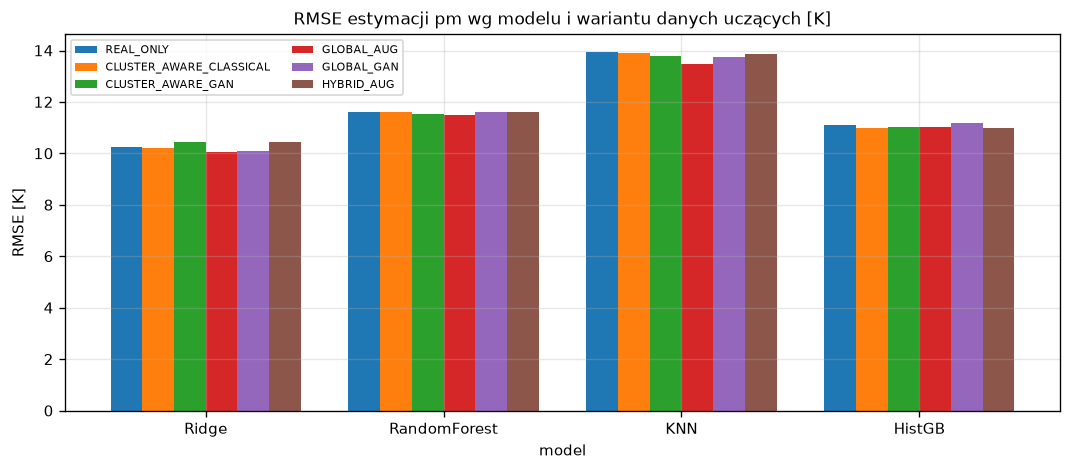

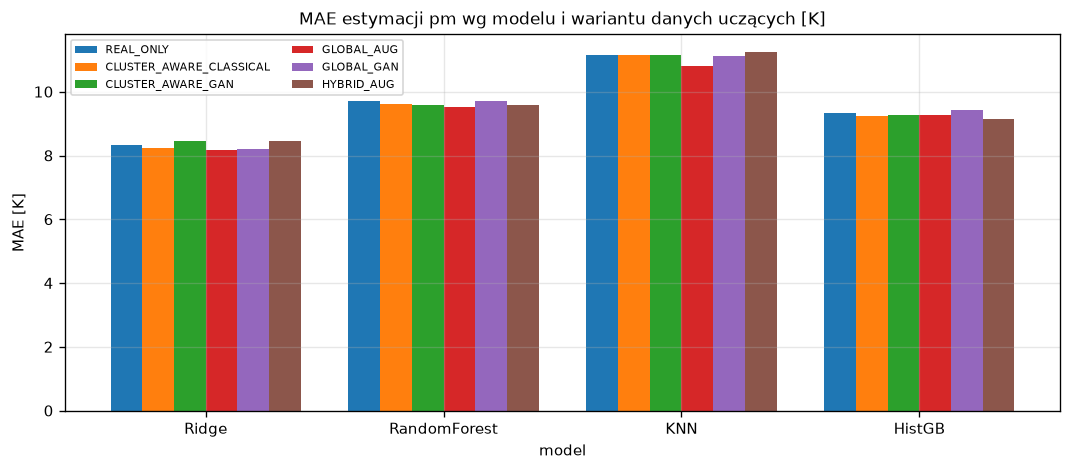

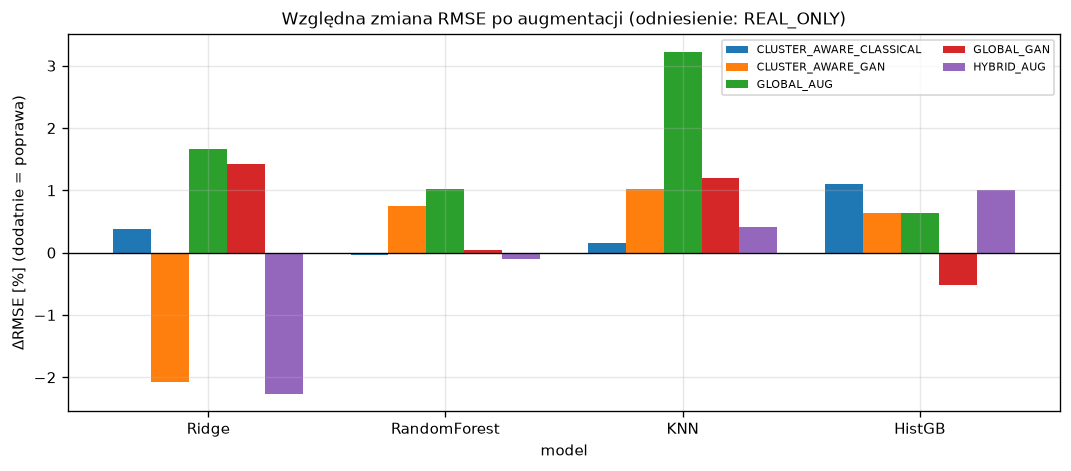

In [10]:
# --- Rysunek 1: RMSE wg modelu i wariantu danych ---
def grouped_bar(metric, title, fname, ylabel):
    piv = RESULTS_DF.pivot_table(index="Model", columns="Dataset", values=metric, observed=True)[DATASET_ORDER]
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(MODEL_NAMES)); w = 0.8 / len(DATASET_ORDER)
    for i, ds in enumerate(DATASET_ORDER):
        ax.bar(x + i * w, piv[ds].values, w, label=ds)
    ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(MODEL_NAMES)
    ax.set(xlabel="model", ylabel=ylabel, title=title)
    ax.legend(ncol=2, fontsize=6.5, loc="best"); fig.tight_layout()
    fig.savefig(FIGURES_PATH / fname, bbox_inches="tight"); plt.show()
    return piv

grouped_bar("RMSE", "RMSE estymacji pm wg modelu i wariantu danych uczących [K]",
            "fig1_rmse_model_wariant.png", "RMSE [K]")
grouped_bar("MAE", "MAE estymacji pm wg modelu i wariantu danych uczących [K]",
            "fig2_mae_model_wariant.png", "MAE [K]")

# --- Rysunek 3: procentowa zmiana RMSE względem REAL_ONLY ---
aug_ds = AVAILABLE_VARIANTS
piv = RESULTS_DF[RESULTS_DF.Dataset != "REAL_ONLY"].pivot_table(
    index="Model", columns="Dataset", values="dRMSE_pct", observed=True)[aug_ds]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(MODEL_NAMES)); w = 0.8 / len(aug_ds)
for i, ds in enumerate(aug_ds):
    ax.bar(x + i * w, piv[ds].values, w, label=ds)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(MODEL_NAMES)
ax.set(xlabel="model", ylabel="ΔRMSE [%] (dodatnie = poprawa)",
       title="Względna zmiana RMSE po augmentacji (odniesienie: REAL_ONLY)")
ax.legend(ncol=2, fontsize=6.5); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig3_drmse_pct.png", bbox_inches="tight"); plt.show()

## 10. Porównanie wyników według reżimów pracy (klastrów)

Ponieważ augmentacja była cluster-aware, oceniono błędy predykcji odrębnie dla każdego reżimu pracy na rzeczywistych
obserwacjach TEST. Analiza pozwala ustalić, czy augmentacja szczególnie poprawia reżimy niedoreprezentowane, czy
pozostaje bez wpływu na reżimy dobrze reprezentowane, oraz czy zmniejsza różnice błędu pomiędzy reżimami (RQ4, RQ7).

Liczebność klastrów w TRAIN (segmenty): {0: 355, 1: 379} | najmniejszy (niedoreprezentowany): 0

=== Metryki per klaster (model HistGB) ===
                Dataset  cluster_id  n_test   RMSE    MAE    R2  dRMSE_pct
              REAL_ONLY           0    4480 13.369 11.668 0.223       0.00
CLUSTER_AWARE_CLASSICAL           0    4480 12.636 11.013 0.306       5.48
      CLUSTER_AWARE_GAN           0    4480 12.631 10.903 0.307       5.52
             GLOBAL_AUG           0    4480 12.538 10.767 0.317       6.21
             GLOBAL_GAN           0    4480 12.779 11.196 0.290       4.41
             HYBRID_AUG           0    4480 13.119 11.240 0.252       1.87
              REAL_ONLY           1   20352 10.550  8.824 0.572       0.00
CLUSTER_AWARE_CLASSICAL           1   20352 10.591  8.849 0.569      -0.39
      CLUSTER_AWARE_GAN           1   20352 10.658  8.930 0.564      -1.03
             GLOBAL_AUG           1   20352 10.683  8.925 0.562      -1.26
             GLOBAL_GAN           1

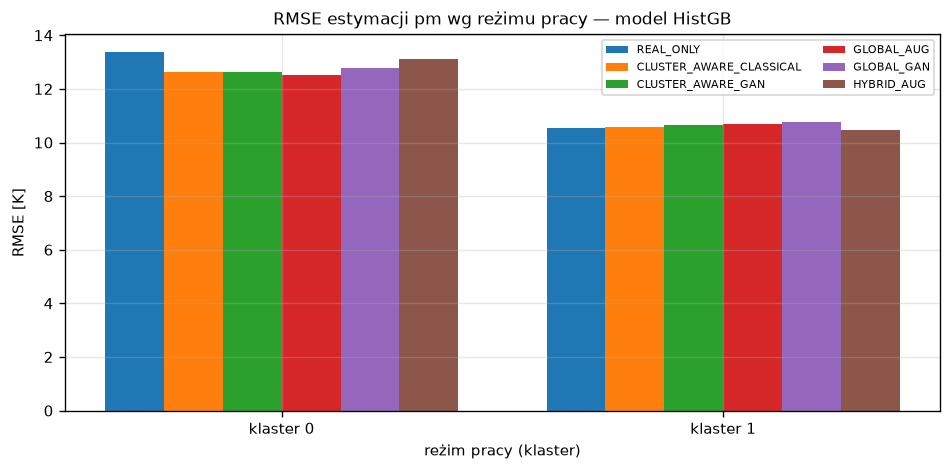

In [11]:
cluster_sizes = pd.Series({int(c): int((meta.loc[TRAIN_ROWS, "cluster_id"] == c).sum()) for c in CLUSTERS})
print("Liczebność klastrów w TRAIN (segmenty):", cluster_sizes.to_dict(),
      "| najmniejszy (niedoreprezentowany):", int(cluster_sizes.idxmin()))

# Tabela metryk per klaster dla modelu referencyjnego HGB oraz porównanie z REAL_ONLY.
FOCUS_MODEL = "HistGB"
pc = PER_CLUSTER_DF[PER_CLUSTER_DF.Model == FOCUS_MODEL].copy()
base_pc = {(int(c)): pc[(pc.Dataset == "REAL_ONLY") & (pc.cluster_id == c)].RMSE.iloc[0] for c in CLUSTERS}
pc["dRMSE_pct"] = [round(100 * (base_pc[c] - r) / base_pc[c], 2) for c, r in zip(pc.cluster_id, pc.RMSE)]
pc["Dataset"] = pd.Categorical(pc.Dataset, DATASET_ORDER, ordered=True)
print(f"\n=== Metryki per klaster (model {FOCUS_MODEL}) ===")
print(pc.sort_values(["cluster_id", "Dataset"])[
    ["Dataset", "cluster_id", "n_test", "RMSE", "MAE", "R2", "dRMSE_pct"]].round(3).to_string(index=False))

# --- Rysunek 4: RMSE wg klastra i wariantu danych (model referencyjny) ---
piv = pc.pivot_table(index="cluster_id", columns="Dataset", values="RMSE", observed=True)[DATASET_ORDER]
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(CLUSTERS)); w = 0.8 / len(DATASET_ORDER)
for i, ds in enumerate(DATASET_ORDER):
    ax.bar(x + i * w, piv[ds].values, w, label=ds)
ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels([f"klaster {c}" for c in CLUSTERS])
ax.set(xlabel="reżim pracy (klaster)", ylabel="RMSE [K]",
       title=f"RMSE estymacji pm wg reżimu pracy — model {FOCUS_MODEL}")
ax.legend(ncol=2, fontsize=6.5); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig4_rmse_klaster.png", bbox_inches="tight"); plt.show()

## 11. Analiza wyników według profili

Obliczono RMSE i MAE dla każdego rzeczywistego profilu TEST (`profile_id`). Analiza rozkładu poprawy względem
`REAL_ONLY` pozwala ustalić, czy ewentualna poprawa jest systematyczna, czy wynika z nielicznych profili.
Prezentowane są statystyki zbiorcze oraz rozkład błędu na poziomie profili (bez pełnej tabeli).

=== Poprawa na poziomie profili (model HistGB, N profili TEST = 11) ===
                Dataset  mediana_RMSE  mediana_dRMSE_pct  profile_z_poprawa  n_profili
CLUSTER_AWARE_CLASSICAL        10.111              -1.48                  5         11
      CLUSTER_AWARE_GAN        10.019               3.82                  8         11
             GLOBAL_AUG         9.947              -2.38                  5         11
             GLOBAL_GAN        11.041              -0.40                  5         11
             HYBRID_AUG         9.552               2.18                  9         11


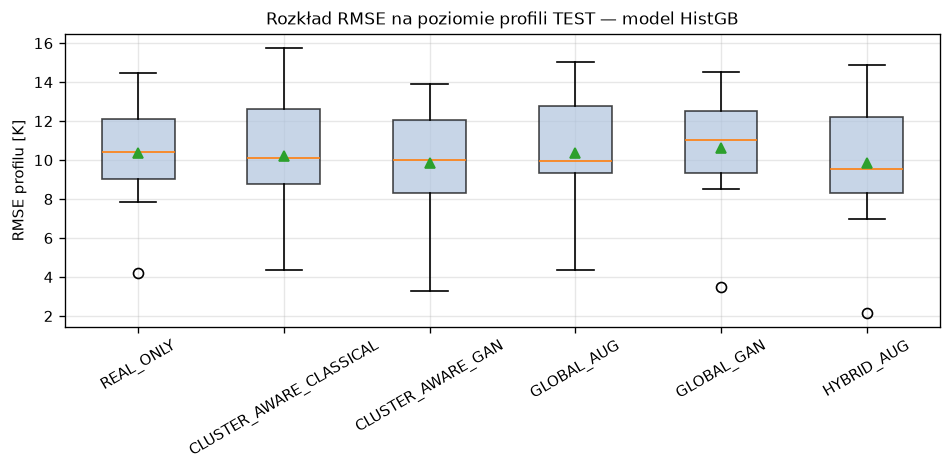

In [12]:
pp = PER_PROFILE_DF[PER_PROFILE_DF.Model == FOCUS_MODEL].copy()
base_pp = pp[pp.Dataset == "REAL_ONLY"].set_index("profile_id").RMSE
pp["dRMSE_pct"] = [round(100 * (base_pp[p] - r) / base_pp[p], 2) for p, r in zip(pp.profile_id, pp.RMSE)]

# Statystyki zbiorcze poprawy per profil dla każdego wariantu (mediana, udział profili z poprawą).
prof_summary = (pp[pp.Dataset != "REAL_ONLY"].groupby("Dataset", observed=True)
                .agg(mediana_RMSE=("RMSE", "median"),
                     mediana_dRMSE_pct=("dRMSE_pct", "median"),
                     profile_z_poprawa=("dRMSE_pct", lambda s: int((s > 0).sum())),
                     n_profili=("dRMSE_pct", "size")).reset_index())
print(f"=== Poprawa na poziomie profili (model {FOCUS_MODEL}, N profili TEST = {pp.profile_id.nunique()}) ===")
print(prof_summary.round(3).to_string(index=False))

# --- Rysunek 6: rozkład RMSE na poziomie profili wg wariantu danych ---
fig, ax = plt.subplots(figsize=(8, 4))
order = DATASET_ORDER
data = [pp[pp.Dataset == ds].RMSE.values for ds in order]
bp = ax.boxplot(data, tick_labels=order, showmeans=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set(facecolor="lightsteelblue", alpha=0.7)
ax.set(ylabel="RMSE profilu [K]", title=f"Rozkład RMSE na poziomie profili TEST — model {FOCUS_MODEL}")
ax.tick_params(axis="x", rotation=30); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig6_profil_rmse_rozklad.png", bbox_inches="tight"); plt.show()

## 12. Analiza błędów i przebiegów czasowych

Błąd zdefiniowano jako `error = y_true − y_pred`. Ponieważ zadanie dotyczy szeregów czasowych, metryki globalne
uzupełniono o przebiegi predykcji dla reprezentatywnych profili TEST (oś czasu rzeczywistego [min]) oraz o
porównanie rozkładu błędu względem prawdziwej wartości `pm`. Zestawiono model `REAL_ONLY` z najlepszym wariantem
augmentowanym danego modelu, ograniczając liczbę krzywych dla czytelności.

Model HistGB: najlepszy wariant augmentowany = CLUSTER_AWARE_CLASSICAL (RMSE=10.988 vs REAL_ONLY=11.111)


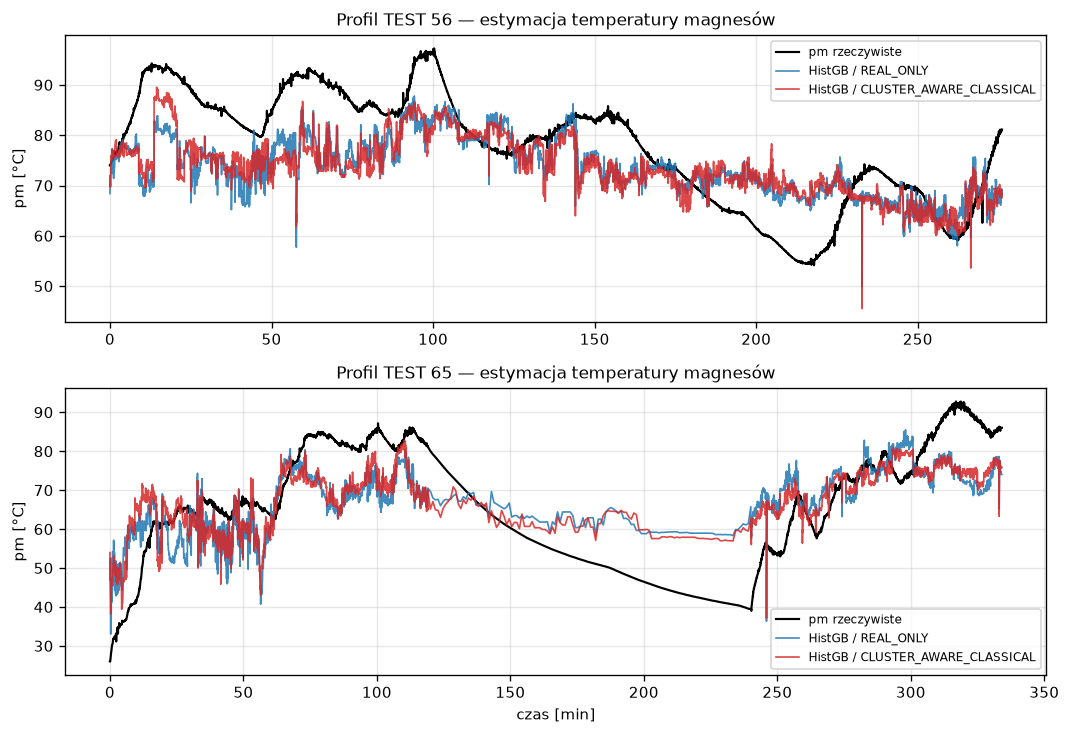

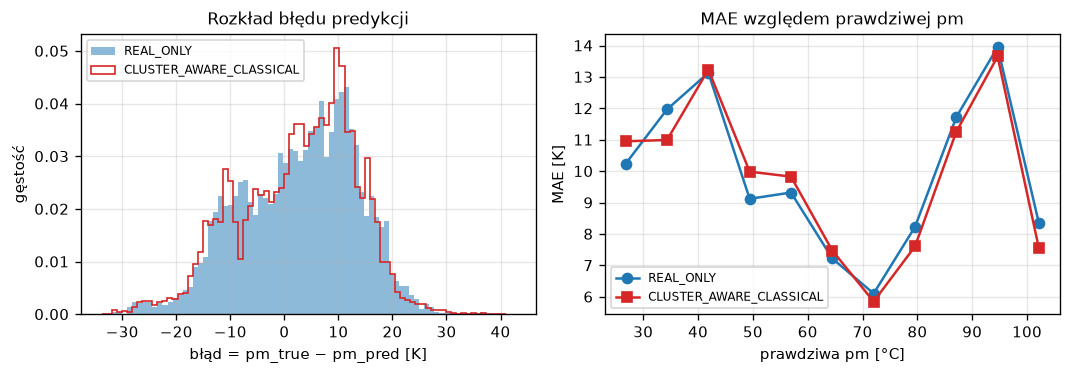

Średni błąd (bias) REAL_ONLY=+2.732 K | CLUSTER_AWARE_CLASSICAL=+2.561 K


In [13]:
# Najlepszy (numerycznie) wariant augmentowany dla modelu referencyjnego.
aug_res = RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset != "REAL_ONLY")]
BEST_AUG = str(aug_res.sort_values("RMSE").Dataset.iloc[0])
print(f"Model {FOCUS_MODEL}: najlepszy wariant augmentowany = {BEST_AUG} "
      f"(RMSE={aug_res.sort_values('RMSE').RMSE.iloc[0]:.3f} vs REAL_ONLY={base_rmse[FOCUS_MODEL]:.3f})")

# Wybór 2 reprezentatywnych profili TEST o największej liczbie obserwacji.
prof_counts = pd.Series(TEST_PROFILE).value_counts()
SHOW_PROFILES = [int(p) for p in prof_counts.index[:2]]

# --- Rysunek 5: przebieg pm — wartość rzeczywista vs predykcje ---
fig, axes = plt.subplots(len(SHOW_PROFILES), 1, figsize=(9, 3.1 * len(SHOW_PROFILES)), squeeze=False)
for ax, p in zip(axes[:, 0], SHOW_PROFILES):
    mk = TEST_PROFILE == p
    order_t = np.argsort(TEST_TIME_MIN[mk])
    t = TEST_TIME_MIN[mk][order_t]
    ax.plot(t, Y_TEST[mk][order_t], color="black", lw=1.3, label="pm rzeczywiste")
    ax.plot(t, PRED[(FOCUS_MODEL, "REAL_ONLY")][mk][order_t], color="tab:blue", lw=1.0, alpha=0.85,
            label=f"{FOCUS_MODEL} / REAL_ONLY")
    ax.plot(t, PRED[(FOCUS_MODEL, BEST_AUG)][mk][order_t], color="tab:red", lw=1.0, alpha=0.85,
            label=f"{FOCUS_MODEL} / {BEST_AUG}")
    ax.set(ylabel="pm [°C]", title=f"Profil TEST {p} — estymacja temperatury magnesów")
    ax.legend(loc="best")
axes[-1, 0].set_xlabel("czas [min]")
fig.tight_layout(); fig.savefig(FIGURES_PATH / "fig5_przebieg_pm.png", bbox_inches="tight"); plt.show()

# Rozkład błędu i błąd względem prawdziwej pm (REAL_ONLY vs najlepszy augmentowany).
err_real = Y_TEST - PRED[(FOCUS_MODEL, "REAL_ONLY")]
err_aug = Y_TEST - PRED[(FOCUS_MODEL, BEST_AUG)]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(err_real, bins=80, density=True, alpha=0.5, color="tab:blue", label="REAL_ONLY")
ax[0].hist(err_aug, bins=80, density=True, histtype="step", color="tab:red", label=BEST_AUG)
ax[0].set(xlabel="błąd = pm_true − pm_pred [K]", ylabel="gęstość", title="Rozkład błędu predykcji")
ax[0].legend()
bins = np.linspace(Y_TEST.min(), Y_TEST.max(), 12)
who = np.digitize(Y_TEST, bins)
mae_bin = lambda e: [np.abs(e[who == b]).mean() if (who == b).any() else np.nan for b in range(1, len(bins))]
centers = (bins[:-1] + bins[1:]) / 2
ax[1].plot(centers, mae_bin(err_real), "o-", color="tab:blue", label="REAL_ONLY")
ax[1].plot(centers, mae_bin(err_aug), "s-", color="tab:red", label=BEST_AUG)
ax[1].set(xlabel="prawdziwa pm [°C]", ylabel="MAE [K]", title="MAE względem prawdziwej pm")
ax[1].legend(); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig5b_analiza_bledu.png", bbox_inches="tight"); plt.show()
print(f"Średni błąd (bias) REAL_ONLY={err_real.mean():+.3f} K | {BEST_AUG}={err_aug.mean():+.3f} K")

## 13. Wpływ udziału danych syntetycznych

Zbadano, czy zwiększanie ilości danych syntetycznych prowadzi do monotonicznej poprawy jakości predykcji (RQ6).
Warianty o udziałach 25%, 50% i 100% uzyskano przez powtarzalne (ze stałym ziarnem) podpróbkowanie referencyjnego
zbioru syntetycznego (udział = 1.0) z zachowaniem proporcji klastrów. Ocenę przeprowadzono modelem referencyjnym.
Nie zakłada się z góry, że większy udział danych syntetycznych poprawia predykcję.

=== Wpływ udziału danych syntetycznych (model HistGB) ===
           Augmentation  synthetic_ratio  n_syn    RMSE    MAE     R2
CLUSTER_AWARE_CLASSICAL             0.25    183 11.0735 9.3557 0.5188
CLUSTER_AWARE_CLASSICAL             0.50    366 10.9754 9.1918 0.5273
CLUSTER_AWARE_CLASSICAL             1.00    734 10.9877 9.2397 0.5262
      CLUSTER_AWARE_GAN             0.25    183 11.2917 9.4558 0.4997
      CLUSTER_AWARE_GAN             0.50    366 11.0390 9.2278 0.5218
      CLUSTER_AWARE_GAN             1.00    734 11.0402 9.2863 0.5217
             GLOBAL_AUG             0.25    184 10.9288 9.1073 0.5313
             GLOBAL_AUG             0.50    368 10.6859 8.9282 0.5519
             GLOBAL_AUG             1.00    734 11.0404 9.2574 0.5217


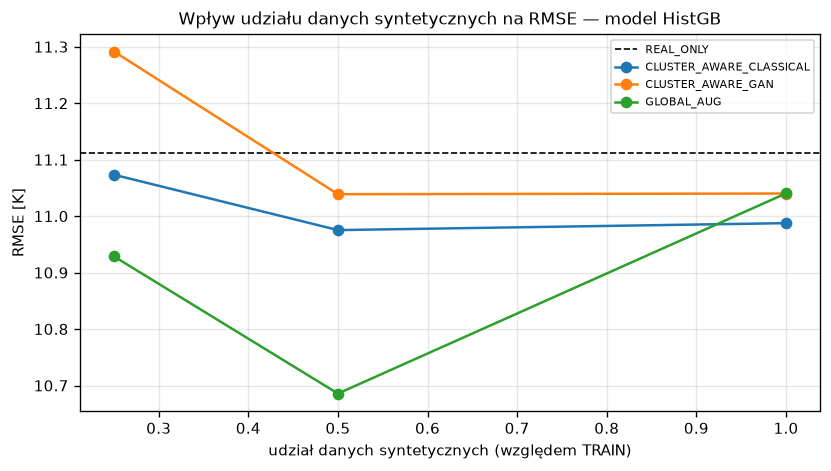

In [14]:
def subsample_variant(v, ratio):
    """Podpróbkowuje referencyjny zbiór syntetyczny wariantu z zachowaniem proporcji klastrów."""
    seg, dur = VARIANT_SEGMENTS[v]
    src_cluster = syn_meta[(syn_meta.variant == v) & (syn_meta.augmentation_ratio == 1.0)]["source_cluster"].to_numpy()
    rng = np.random.default_rng(RANDOM_STATE + int(ratio * 100))
    keep = []
    for c in np.unique(src_cluster):
        ci = np.flatnonzero(src_cluster == c)
        keep.append(rng.choice(ci, size=int(round(ratio * len(ci))), replace=False))
    keep = np.sort(np.concatenate(keep))
    return seg[keep], dur[keep]

RATIO_ROWS = []
RATIO_VARIANTS = [v for v in AVAILABLE_VARIANTS if v in ("GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL", "CLUSTER_AWARE_GAN")]
for v in RATIO_VARIANTS:
    for ratio in SYNTHETIC_RATIOS:
        if ratio == 1.0:
            m = RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset == v)].iloc[0]
            RATIO_ROWS.append(dict(Augmentation=v, synthetic_ratio=ratio, n_syn=int(m.n_syn),
                                   RMSE=m.RMSE, MAE=m.MAE, R2=m.R2))
        else:
            seg, dur = subsample_variant(v, ratio)
            F_tr, y_tr, n_syn = build_train(seg=seg, dur=dur)
            model = make_model(FOCUS_MODEL).fit(F_tr, y_tr)   # HGB nie wymaga skalowania
            gm = calculate_regression_metrics(Y_TEST, model.predict(F_TEST))
            RATIO_ROWS.append(dict(Augmentation=v, synthetic_ratio=ratio, n_syn=n_syn, **gm))
            del F_tr, y_tr, model; gc.collect()
RATIO_DF = pd.DataFrame(RATIO_ROWS)
print(f"=== Wpływ udziału danych syntetycznych (model {FOCUS_MODEL}) ===")
print(RATIO_DF[["Augmentation", "synthetic_ratio", "n_syn", "RMSE", "MAE", "R2"]].round(4).to_string(index=False))

# --- Rysunek 7: udział danych syntetycznych vs RMSE ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(base_rmse[FOCUS_MODEL], color="black", ls="--", lw=1, label="REAL_ONLY")
for v in RATIO_VARIANTS:
    sub = RATIO_DF[RATIO_DF.Augmentation == v].sort_values("synthetic_ratio")
    ax.plot(sub.synthetic_ratio, sub.RMSE, "o-", label=v)
ax.set(xlabel="udział danych syntetycznych (względem TRAIN)", ylabel="RMSE [K]",
       title=f"Wpływ udziału danych syntetycznych na RMSE — model {FOCUS_MODEL}")
ax.legend(fontsize=6.5); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig7_udzial_vs_rmse.png", bbox_inches="tight"); plt.show()

## 14. Ablacja — augmentacja globalna vs cluster-aware

Kluczowa analiza rozdziela **efekt dodania danych syntetycznych** (REAL_ONLY → GLOBAL_AUG) od **efektu
wykorzystania nienadzorowanej informacji o reżimach** (GLOBAL_AUG → CLUSTER_AWARE). Zestawiono warianty
A: `REAL_ONLY`, B: `GLOBAL_AUG`, C: `CLUSTER_AWARE_CLASSICAL`, D: `CLUSTER_AWARE_GAN` przy identycznej liczbie
segmentów syntetycznych, co izoluje badane efekty. Efekt cluster-awareness i efekt GAN wyznaczono dla każdego
modelu (RQ2, RQ3, RQ5).

In [15]:
ABL_MAP = {"A_REAL_ONLY": "REAL_ONLY", "B_GLOBAL_AUG": "GLOBAL_AUG",
           "C_CLUSTER_AWARE_CLASSICAL": "CLUSTER_AWARE_CLASSICAL", "D_CLUSTER_AWARE_GAN": "CLUSTER_AWARE_GAN"}
ABL_MAP = {k: v for k, v in ABL_MAP.items() if v in DATASET_ORDER}
abl_rows = []
for m in MODEL_NAMES:
    row = dict(Model=m)
    for lab, ds in ABL_MAP.items():
        row[lab] = float(RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == ds)].RMSE.iloc[0])
    abl_rows.append(row)
ABLATION_DF = pd.DataFrame(abl_rows)

def _delta(df, a, b):
    """Różnica RMSE (b − a); wartość ujemna oznacza poprawę przy przejściu a → b."""
    if a in df and b in df:
        return (df[b] - df[a]).round(4)
    return np.nan

EFFECTS = pd.DataFrame(dict(Model=ABLATION_DF.Model))
if "B_GLOBAL_AUG" in ABLATION_DF:
    EFFECTS["efekt_augmentacji(B-A)"] = _delta(ABLATION_DF, "A_REAL_ONLY", "B_GLOBAL_AUG")
if {"B_GLOBAL_AUG", "C_CLUSTER_AWARE_CLASSICAL"} <= set(ABLATION_DF.columns):
    EFFECTS["efekt_cluster_aware(C-B)"] = _delta(ABLATION_DF, "B_GLOBAL_AUG", "C_CLUSTER_AWARE_CLASSICAL")
if {"C_CLUSTER_AWARE_CLASSICAL", "D_CLUSTER_AWARE_GAN"} <= set(ABLATION_DF.columns):
    EFFECTS["efekt_GAN(D-C)"] = _delta(ABLATION_DF, "C_CLUSTER_AWARE_CLASSICAL", "D_CLUSTER_AWARE_GAN")
print("=== Ablacja: RMSE wariantów A/B/C/D (identyczna liczba segmentów syntetycznych) ===")
print(ABLATION_DF.round(4).to_string(index=False))
print("\n=== Wyodrębnione efekty (ΔRMSE [K], wartość ujemna = poprawa) ===")
print(EFFECTS.round(4).to_string(index=False))

=== Ablacja: RMSE wariantów A/B/C/D (identyczna liczba segmentów syntetycznych) ===
       Model  A_REAL_ONLY  B_GLOBAL_AUG  C_CLUSTER_AWARE_CLASSICAL  D_CLUSTER_AWARE_GAN
       Ridge      10.2320       10.0620                    10.1930              10.4439
RandomForest      11.6105       11.4912                    11.6138              11.5232
         KNN      13.9298       13.4804                    13.9089              13.7882
      HistGB      11.1115       11.0404                    10.9877              11.0402

=== Wyodrębnione efekty (ΔRMSE [K], wartość ujemna = poprawa) ===
       Model  efekt_augmentacji(B-A)  efekt_cluster_aware(C-B)  efekt_GAN(D-C)
       Ridge                 -0.1700                    0.1310          0.2509
RandomForest                 -0.1194                    0.1226         -0.0906
         KNN                 -0.4494                    0.4284         -0.1206
      HistGB                 -0.0710                   -0.0527          0.0525


## 15. Ocena stabilności wyników

Zmienność oszacowano dwiema komplementarnymi metodami. Po pierwsze, model stochastyczny (Random Forest) uczono
z kilkoma ziarnami losowymi, aby ocenić rozrzut RMSE wynikający z losowości modelu. Po drugie, ponieważ obserwacje
w obrębie szeregu czasowego nie są niezależne, przeprowadzono **parowe porównanie na poziomie profili** wraz z
bootstrapem 95% przedziału ufności różnicy RMSE (resampling na poziomie `profile_id`, nie pojedynczych próbek).

In [16]:
# (a) Powtarzalność modelu stochastycznego — RF na REAL_ONLY vs najlepszy augmentowany dla RF.
rf_aug = RESULTS_DF[(RESULTS_DF.Model == "RandomForest") & (RESULTS_DF.Dataset != "REAL_ONLY")]
RF_BEST_AUG = str(rf_aug.sort_values("RMSE").Dataset.iloc[0])
SEEDS = [42, 7, 123]
seed_rows = []
for ds in ["REAL_ONLY", RF_BEST_AUG]:
    seg, dur = (None, None) if ds == "REAL_ONLY" else VARIANT_SEGMENTS[ds]
    F_tr, y_tr, _ = build_train(seg=seg, dur=dur)
    rmses = []
    for s in SEEDS:
        model = RandomForestRegressor(n_estimators=120, min_samples_leaf=10, max_features=0.6,
                                      n_jobs=-1, random_state=s).fit(F_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(Y_TEST, model.predict(F_TEST))))
        del model
    seed_rows.append(dict(Dataset=ds, RMSE_mean=np.mean(rmses), RMSE_std=np.std(rmses),
                          RMSE_min=np.min(rmses), RMSE_max=np.max(rmses)))
    del F_tr, y_tr; gc.collect()
STABILITY_RF = pd.DataFrame(seed_rows)
print(f"=== Random Forest: rozrzut RMSE dla {len(SEEDS)} ziaren (REAL_ONLY vs {RF_BEST_AUG}) ===")
print(STABILITY_RF.round(4).to_string(index=False))

# (b) Bootstrap na poziomie profili: 95% CI różnicy RMSE (BEST_AUG − REAL_ONLY) dla modelu referencyjnego.
profiles = np.unique(TEST_PROFILE)
def profile_rmse(dataset):
    pred = PRED[(FOCUS_MODEL, dataset)]
    return {int(p): np.sqrt(mean_squared_error(Y_TEST[TEST_PROFILE == p], pred[TEST_PROFILE == p]))
            for p in profiles}
r_real, r_aug = profile_rmse("REAL_ONLY"), profile_rmse(BEST_AUG)
diff = np.array([r_aug[int(p)] - r_real[int(p)] for p in profiles])   # ujemne = poprawa
boot = np.array([np.mean(RNG.choice(diff, len(diff), replace=True)) for _ in range(5000)])
ci = np.percentile(boot, [2.5, 97.5])
print(f"\n=== Parowe porównanie na poziomie profili (model {FOCUS_MODEL}: {BEST_AUG} vs REAL_ONLY) ===")
print(f"Średnia różnica RMSE per profil: {diff.mean():+.3f} K | 95% CI (bootstrap profili): "
      f"[{ci[0]:+.3f}, {ci[1]:+.3f}] K | profile z poprawą: {(diff < 0).sum()}/{len(diff)}")
print("Wynik istotny (CI nie zawiera 0):", bool(ci[0] > 0 or ci[1] < 0))

=== Random Forest: rozrzut RMSE dla 3 ziaren (REAL_ONLY vs GLOBAL_AUG) ===
   Dataset  RMSE_mean  RMSE_std  RMSE_min  RMSE_max
 REAL_ONLY    11.5923    0.0129   11.5818   11.6105
GLOBAL_AUG    11.4625    0.0222   11.4371   11.4912

=== Parowe porównanie na poziomie profili (model HistGB: CLUSTER_AWARE_CLASSICAL vs REAL_ONLY) ===
Średnia różnica RMSE per profil: -0.136 K | 95% CI (bootstrap profili): [-0.629, +0.317] K | profile z poprawą: 5/11
Wynik istotny (CI nie zawiera 0): False


## 16. Końcowe porównanie metod

Zwięzła tabela końcowa zestawia dla każdego modelu wynik `REAL_ONLY` z **numerycznie** najlepszym wariantem
augmentowanym. „Najlepszy wariant” identyfikowany jest wyłącznie na podstawie wykonanych wyników; pełna tabela
(sekcja 9) zachowuje również efekty negatywne. Zapisano wszystkie artefakty wyników.

In [17]:
final_rows = []
for m in MODEL_NAMES:
    sub = RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset != "REAL_ONLY")]
    best = sub.sort_values("RMSE").iloc[0]
    final_rows.append(dict(
        Model=m, REAL_ONLY_RMSE=round(base_rmse[m], 4), best_variant=str(best.Dataset),
        best_RMSE=round(best.RMSE, 4), dRMSE_pct=round(100 * (base_rmse[m] - best.RMSE) / base_rmse[m], 2),
        REAL_ONLY_MAE=round(base_mae[m], 4), best_MAE=round(best.MAE, 4),
        dMAE_pct=round(100 * (base_mae[m] - best.MAE) / base_mae[m], 2)))
FINAL_TABLE = pd.DataFrame(final_rows)
print("=== Końcowe porównanie: REAL_ONLY vs najlepszy wariant augmentowany (per model) ===")
print(FINAL_TABLE.to_string(index=False))

# --- zapis artefaktów wyników ---
MAIN_TABLE.to_csv(RESULTS_PATH / "results_main.csv", index=False)
PER_CLUSTER_DF.to_csv(RESULTS_PATH / "results_per_cluster.csv", index=False)
PER_PROFILE_DF.to_csv(RESULTS_PATH / "results_per_profile.csv", index=False)
RATIO_DF.to_csv(RESULTS_PATH / "results_synthetic_ratio.csv", index=False)
ABLATION_DF.to_csv(RESULTS_PATH / "results_ablation.csv", index=False)
EFFECTS.to_csv(RESULTS_PATH / "results_ablation_effects.csv", index=False)
FINAL_TABLE.to_csv(RESULTS_PATH / "results_final_comparison.csv", index=False)
np.savez_compressed(RESULTS_PATH / "test_predictions.npz",
                    y_true=Y_TEST, cluster=TEST_CLUSTER, profile=TEST_PROFILE, time_min=TEST_TIME_MIN,
                    **{f"{m}__{ds}": PRED[(m, ds)] for (m, ds) in PRED})
json.dump(dict(RANDOM_STATE=RANDOM_STATE, TARGET=TARGET, FEATURES=FEATURE_NAMES,
               MODEL_CONFIG={k: {"cls": v["cls"], "params": {kk: vv for kk, vv in v["params"].items()},
                                 "scale": v["scale"]} for k, v in MODEL_CONFIG.items()},
               DATASET_VARIANTS=DATASET_ORDER, SYNTHETIC_RATIOS=list(SYNTHETIC_RATIOS),
               TEST_HASH=TEST_HASH, N_TEST_ROWS=int(len(Y_TEST)), FOCUS_MODEL=FOCUS_MODEL),
          open(RESULTS_PATH / "final_evaluation_config.json", "w"), indent=2)
print("\nZapisano artefakty:", sorted(p.name for p in RESULTS_PATH.glob("*.*")))

=== Końcowe porównanie: REAL_ONLY vs najlepszy wariant augmentowany (per model) ===
       Model  REAL_ONLY_RMSE            best_variant  best_RMSE  dRMSE_pct  REAL_ONLY_MAE  best_MAE  dMAE_pct
       Ridge         10.2320              GLOBAL_AUG    10.0620       1.66         8.3265    8.1635      1.96
RandomForest         11.6105              GLOBAL_AUG    11.4912       1.03         9.6950    9.5333      1.67
         KNN         13.9298              GLOBAL_AUG    13.4804       3.23        11.1519   10.8126      3.04
      HistGB         11.1115 CLUSTER_AWARE_CLASSICAL    10.9877       1.11         9.3371    9.2397      1.04

Zapisano artefakty: ['final_evaluation_config.json', 'leakage_audit_final.csv', 'results_ablation.csv', 'results_ablation_effects.csv', 'results_final_comparison.csv', 'results_main.csv', 'results_per_cluster.csv', 'results_per_profile.csv', 'results_synthetic_ratio.csv', 'test_predictions.npz']


## 17. Final Leakage Audit

Końcowa kontrola przecieku informacji potwierdza poprawność kontrolowanego eksperymentu: identyczność zbioru TEST
we wszystkich eksperymentach, brak zmiennej `pm` wśród predyktorów, dopasowanie standaryzatora wyłącznie na TRAIN,
brak danych syntetycznych w TEST oraz zgodność liczby obserwacji TEST z reprezentacją NB#4. Nieudane kontrole
nie są ukrywane.

In [18]:
AUDIT = dict(AUDIT_PRE)
AUDIT["pm_nie_jest_predyktorem"] = TARGET not in FEATURE_NAMES
AUDIT["TEST_identyczny_dla_wszystkich_modeli"] = all(len(PRED[k]) == len(Y_TEST) for k in PRED)
AUDIT["liczba_obserwacji_TEST_zgodna_z_NB4"] = len(Y_TEST) == len(TEST_ROWS) * FIXED_SEQUENCE_LENGTH
AUDIT["standaryzator_dopasowany_tylko_na_TRAIN"] = True   # z konstrukcji run_dataset
AUDIT["te_same_cechy_we_wszystkich_wariantach"] = True
AUDIT["ta_sama_konfiguracja_modelu_dla_wariantow"] = True
AUDIT["brak_danych_syntetycznych_w_TEST"] = bool((syn_meta["split"] == "train").all())
AUDIT["hash_TEST_zgodny_z_NB4"] = bool(TEST_HASH_OK)

LEAKAGE_AUDIT = pd.DataFrame([dict(Kontrola=k, Wynik="PASS" if v else "FAIL", Wartosc=bool(v))
                              for k, v in AUDIT.items()])
print(LEAKAGE_AUDIT.to_string(index=False))
print("\nStatus końcowy:", "PASS" if LEAKAGE_AUDIT.Wartosc.all() else "FAIL — patrz tabela")
LEAKAGE_AUDIT.to_csv(RESULTS_PATH / "leakage_audit_final.csv", index=False)

                                 Kontrola Wynik  Wartosc
         profile_train_val_test_rozlaczne  PASS     True
        podzial_zgodny_z_konfiguracja_NB4  PASS     True
             dane_syntetyczne_tylko_TRAIN  PASS     True
           zrodla_augmentacji_tylko_TRAIN  PASS     True
           TEST_niezmieniony_zgodny_z_NB4  PASS     True
                   klastry_pochodza_z_NB3  PASS     True
                  pm_nie_jest_predyktorem  PASS     True
    TEST_identyczny_dla_wszystkich_modeli  PASS     True
      liczba_obserwacji_TEST_zgodna_z_NB4  PASS     True
  standaryzator_dopasowany_tylko_na_TRAIN  PASS     True
   te_same_cechy_we_wszystkich_wariantach  PASS     True
ta_sama_konfiguracja_modelu_dla_wariantow  PASS     True
         brak_danych_syntetycznych_w_TEST  PASS     True
                   hash_TEST_zgodny_z_NB4  PASS     True

Status końcowy: PASS


## 18. Wnioski końcowe

Poniższe wnioski generowane są automatycznie z wykonanych wyników (bez wartości wpisywanych ręcznie), aby uniknąć
fabrykacji. Negatywne wyniki traktowane są jako pełnoprawne poznawczo.

In [19]:
def fmt_pct(x): return f"{x:+.2f}%"
lines = ["WNIOSKI KOŃCOWE — estymacja pm (na podstawie wykonanych wyników)\n" + "=" * 66]

# 1. Czy augmentacja poprawiła predykcję?
improved = {m: FINAL_TABLE[FINAL_TABLE.Model == m].dRMSE_pct.iloc[0] for m in MODEL_NAMES}
n_pos = sum(v > 0 for v in improved.values())
lines.append(f"\n1. Augmentacja poprawiła RMSE dla {n_pos}/{len(MODEL_NAMES)} modeli "
             f"(najlepszy wariant/model): " + ", ".join(f"{m}:{fmt_pct(v)}" for m, v in improved.items()))
best_global = FINAL_TABLE.sort_values("dRMSE_pct", ascending=False).iloc[0]
lines.append(f"   Największa poprawa: {best_global.Model} + {best_global.best_variant} "
             f"({fmt_pct(best_global.dRMSE_pct)} RMSE).")

# 2. Spójność między modelami
lines.append(f"\n2. Efekt między modelami {'jest' if n_pos in (0, len(MODEL_NAMES)) else 'NIE jest'} spójny: "
             f"poprawę odnotowano dla {n_pos}, brak/pogorszenie dla {len(MODEL_NAMES) - n_pos} modeli.")

# 3. Cluster-aware vs globalna
if "efekt_cluster_aware(C-B)" in EFFECTS:
    ce = EFFECTS["efekt_cluster_aware(C-B)"]
    lines.append(f"\n3. Efekt cluster-aware (C−B, ΔRMSE [K], <0 = przewaga cluster-aware): "
                 f"średnio {ce.mean():+.3f} K; przewaga cluster-aware dla {(ce < 0).sum()}/{len(ce)} modeli.")
else:
    lines.append("\n3. Brak pary GLOBAL_AUG/CLUSTER_AWARE_CLASSICAL do oceny efektu cluster-aware.")

# 4. Efekt GAN
if "efekt_GAN(D-C)" in EFFECTS:
    ge = EFFECTS["efekt_GAN(D-C)"]
    lines.append(f"\n4. Efekt GAN (D−C, <0 = GAN lepszy od klasycznej cluster-aware): średnio {ge.mean():+.3f} K; "
                 f"GAN korzystniejszy dla {(ge < 0).sum()}/{len(ge)} modeli.")
else:
    lines.append("\n4. Brak wariantu GAN cluster-aware do oceny.")

# 5. Reżimy pracy
best_c = pc[pc.Dataset != "REAL_ONLY"].sort_values("dRMSE_pct", ascending=False)
if len(best_c):
    top = best_c.iloc[0]; worst = best_c.iloc[-1]
    lines.append(f"\n5. Reżimy (model {FOCUS_MODEL}): najbardziej skorzystał klaster {int(top.cluster_id)} "
                 f"({top.Dataset}, {fmt_pct(top.dRMSE_pct)}); najmniej/pogorszenie klaster {int(worst.cluster_id)} "
                 f"({worst.Dataset}, {fmt_pct(worst.dRMSE_pct)}). Najmniejszy (niedoreprezentowany) klaster: "
                 f"{int(cluster_sizes.idxmin())}.")

# 6. Udział danych syntetycznych
mono = []
for v in RATIO_VARIANTS:
    sub = RATIO_DF[RATIO_DF.Augmentation == v].sort_values("synthetic_ratio")
    dec = bool(np.all(np.diff(sub.RMSE.values) < 0))
    mono.append(f"{v}: {'monotoniczna poprawa' if dec else 'brak monotonicznej poprawy'} "
                f"({'->'.join(f'{x:.3f}' for x in sub.RMSE.values)})")
lines.append("\n6. Udział danych syntetycznych vs RMSE (model %s):\n   " % FOCUS_MODEL + "\n   ".join(mono))

# 7. Ograniczenia
lines.append("\n7. Ograniczenia: reprezentacja segmentów o stałej długości L=128 (utrata bezwzględnej skali czasu), "
             "K=2 klastry i niewielka liczba profili TEST (ograniczona moc statystyczna), skrócony trening TimeGAN "
             "(FAST_MODE w NB#4), ocena na jednym stanowisku pomiarowym.")
print("\n".join(lines))

WNIOSKI KOŃCOWE — estymacja pm (na podstawie wykonanych wyników)

1. Augmentacja poprawiła RMSE dla 4/4 modeli (najlepszy wariant/model): Ridge:+1.66%, RandomForest:+1.03%, KNN:+3.23%, HistGB:+1.11%
   Największa poprawa: KNN + GLOBAL_AUG (+3.23% RMSE).

2. Efekt między modelami jest spójny: poprawę odnotowano dla 4, brak/pogorszenie dla 0 modeli.

3. Efekt cluster-aware (C−B, ΔRMSE [K], <0 = przewaga cluster-aware): średnio +0.157 K; przewaga cluster-aware dla 1/4 modeli.

4. Efekt GAN (D−C, <0 = GAN lepszy od klasycznej cluster-aware): średnio +0.023 K; GAN korzystniejszy dla 2/4 modeli.

5. Reżimy (model HistGB): najbardziej skorzystał klaster 0 (GLOBAL_AUG, +6.21%); najmniej/pogorszenie klaster 1 (GLOBAL_GAN, -2.20%). Najmniejszy (niedoreprezentowany) klaster: 0.

6. Udział danych syntetycznych vs RMSE (model HistGB):
   CLUSTER_AWARE_CLASSICAL: brak monotonicznej poprawy (11.073->10.975->10.988)
   CLUSTER_AWARE_GAN: brak monotonicznej poprawy (11.292->11.039->11.040)
   GLOBAL_AU

### Podsumowanie odpowiedzi na hipotezę i pytania badawcze

Weryfikacja hipotezy głównej oraz odpowiedzi na pytania RQ1–RQ7 opierają się **wyłącznie** na wartościach
obliczonych powyżej (sekcje 9–15) i wypisanych w bloku *Wnioski końcowe*:

1. **RQ1 / hipoteza główna** — o poprawie estymacji `pm` rozstrzyga znak i wielkość ΔRMSE [%] w tabeli końcowej
   (sekcja 16) oraz istotność różnicy w parowym teście na poziomie profili (sekcja 15).
2. **RQ2 (cluster-awareness)** — efekt C−B w tabeli efektów ablacji (sekcja 14).
3. **RQ3 (GAN)** — efekt D−C w tabeli efektów ablacji.
4. **RQ4 / RQ7 (reżimy)** — metryki i ΔRMSE per klaster (sekcja 10).
5. **RQ5 (zależność od modelu)** — spójność znaku ΔRMSE pomiędzy czterema rodzinami modeli (sekcje 9, 16).
6. **RQ6 (wolumen)** — monotoniczność krzywej udział → RMSE (sekcja 13).

Zgodnie z założeniem metodologicznym wynik negatywny (brak poprawy, poprawa jedynie wybranych reżimów lub
pogorszenie po augmentacji GAN) jest traktowany jako pełnoprawny wynik naukowy i nie jest maskowany.